# Campaign Funnel & Channel Performance Analysis

## 1. Project Overview

### Dataset Context

This project uses the **Marketing Campaign Performance Dataset** from Kaggle.

Dataset source: [Marketing Campaign Performance Dataset on Kaggle](https://www.kaggle.com/datasets/mirzayasirabdullah07/marketing-campaign-performance-dataset/data)

The dataset was published on Kaggle by **Mirza Yasir Abdullah Baig**. According to the dataset description, it contains performance metrics for **10,000 marketing campaigns** executed across multiple marketing channels in 2025, including Search, Display, Social, Email, and Influencer channels.

The dataset is not presented as data from one specific real company. Instead, it is used here as a portfolio dataset to simulate a practical marketing analytics task: evaluating campaign performance, diagnosing funnel efficiency, and identifying optimization opportunities.

Each row represents one marketing campaign record. The main fields include campaign ID, start date, end date, marketing channel, impressions, clicks, leads, conversions, cost, revenue, and ROI.

### Business Context

For a marketing team, high traffic does not always mean strong business performance. A campaign may generate many impressions and clicks, but still fail to create enough leads, conversions, or revenue.

Because of this, campaign performance should not be evaluated by one metric only. A good analysis needs to look at both funnel efficiency and cost efficiency.

This project uses campaign performance data to identify which channels perform well, where the funnel loses efficiency, and which campaigns should be scaled, optimized, investigated, or reduced.

### Main Business Question

Where does the marketing campaign funnel lose efficiency, and which campaigns or channels should be prioritized for optimization?

### Analytical Approach

This project uses a simple campaign performance analysis approach.

The analysis focuses on:

- Click-through performance
- Lead generation efficiency
- Conversion efficiency
- Cost efficiency
- Revenue efficiency
- Campaign prioritization

The goal is to translate campaign data into practical business recommendations, not just report marketing numbers.

### Expected Output

The final output will include:

- A cleaned campaign performance dataset
- Key marketing KPIs
- Overall funnel performance
- Channel-level performance summary
- Campaign-level winners and underperformers
- Bottleneck diagnosis
- Business recommendations for campaign optimization

## 2. Setup and Data Loading

This section imports the basic Python libraries and loads the marketing campaign dataset.

The purpose of this step is to check whether the dataset can be loaded correctly before starting the analysis.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

os.chdir(r"D:\data-portfolio\05_marketing_campaign_funnel_analysis")

df = pd.read_csv("data/marketing_campaign_performance_10000.csv")

df.head()

,CampaignID,StartDate,EndDate,Channel,Impressions,Clicks,Leads,Conversions,Cost_USD,Revenue_USD,ROI
0,CAMP00001,2025-04-13,2025-04-19,Search,293520,23335,11643,5389,1052.39,2236.02,1.12
1,CAMP00002,2025-12-15,2025-12-24,Search,200340,15841,6601,2498,3964.90,11740.15,1.96
2,CAMP00003,2025-09-28,2025-10-06,Email,239365,16478,8043,3397,1000.39,1902.24,0.90
3,CAMP00004,2025-04-17,2025-04-30,Search,156382,2672,1014,342,1252.63,2209.74,0.76
4,CAMP00005,2025-03-13,2025-03-22,Influencer,285472,4155,1521,565,4935.48,14111.31,1.86


### Initial Preview

The dataset was loaded successfully.

The first five rows show that the data is at campaign level. Each record includes campaign dates, marketing channel, impressions, clicks, leads, conversions, cost, revenue, and ROI.

This structure is suitable for analyzing campaign funnel performance and channel efficiency.

## 3. Initial Data Inspection

This section checks the dataset structure and reviews potential data quality issues before analysis.

The goal is to review dataset size, column types, missing values, duplicate rows, funnel logic, dataset coverage, and numeric ranges.

### 3.1 Dataset Size

First, I check the number of rows and columns in the dataset.

In [2]:
basic_structure = pd.DataFrame({
    "Metric": ["Rows", "Columns"],
    "Value": [df.shape[0], df.shape[1]]
})

basic_structure

,Metric,Value
0,Rows,10000
1,Columns,11


### 3.2 Column Overview

Next, I check each column's data type and missing values.

In [3]:
column_summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Missing Values": df.isna().sum().values,
    "Missing %": (df.isna().mean() * 100).round(2).values
})

column_summary

,Column,Data Type,Missing Values,Missing %
0,CampaignID,object,0,0.0
1,StartDate,object,0,0.0
2,EndDate,object,0,0.0
3,Channel,object,0,0.0
4,Impressions,int64,0,0.0
5,Clicks,int64,0,0.0
6,Leads,int64,0,0.0
7,Conversions,int64,0,0.0
8,Cost_USD,float64,0,0.0
9,Revenue_USD,float64,0,0.0


### 3.3 Key Data Quality Checks

Before calculating marketing KPIs, I check duplicate rows, missing records, invalid date ranges, invalid funnel order, and negative numeric values.

In [4]:
invalid_funnel = (
    (df["Impressions"] < df["Clicks"]) |
    (df["Clicks"] < df["Leads"]) |
    (df["Leads"] < df["Conversions"])
)

invalid_dates = pd.to_datetime(df["EndDate"]) < pd.to_datetime(df["StartDate"])

numeric_cols = ["Impressions", "Clicks", "Leads", "Conversions", "Cost_USD", "Revenue_USD", "ROI"]

data_quality_checks = pd.DataFrame({
    "Check": [
        "Duplicate rows",
        "Rows with missing values",
        "Invalid date ranges",
        "Invalid funnel order",
        "Rows with negative numeric values"
    ],
    "Count": [
        df.duplicated().sum(),
        df.isna().any(axis=1).sum(),
        invalid_dates.sum(),
        invalid_funnel.sum(),
        (df[numeric_cols] < 0).any(axis=1).sum()
    ]
})

data_quality_checks

,Check,Count
0,Duplicate rows,0
1,Rows with missing values,0
2,Invalid date ranges,0
3,Invalid funnel order,0
4,Rows with negative numeric values,0


### 3.4 Dataset Coverage

I also check the number of campaigns, available marketing channels, and campaign date range.

In [5]:
dataset_coverage = pd.DataFrame({
    "Metric": [
        "Unique Campaigns",
        "Marketing Channels",
        "Start Date",
        "End Date"
    ],
    "Value": [
        df["CampaignID"].nunique(),
        ", ".join(df["Channel"].unique()),
        df["StartDate"].min(),
        df["EndDate"].max()
    ]
})

dataset_coverage

,Metric,Value
0,Unique Campaigns,10000
1,Marketing Channels,"Search, Email, Influencer, Social, Display"
2,Start Date,2025-01-01
3,End Date,2026-01-15


### 3.5 Numeric Summary

Finally, I review the basic statistics of the main numeric columns to understand their ranges before creating marketing KPIs.

In [6]:
df[numeric_cols].describe().round(2)

,Impressions,Clicks,Leads,Conversions,Cost_USD,Revenue_USD,ROI
count,10000.00,10000.00,10000.00,10000.0,10000.00,10000.00,10000.00
mean,152260.64,8338.99,2512.46,1010.7,2552.36,5102.65,1.00
std,85251.71,6546.33,2321.03,1019.4,1427.69,3309.33,0.58
min,5043.00,72.00,10.00,4.0,100.23,113.64,0.00
25%,78956.00,2981.00,779.00,295.0,1319.62,2385.74,0.50
50%,151505.50,6588.50,1777.00,670.0,2529.68,4659.36,0.99
75%,225853.25,12404.25,3550.25,1391.0,3821.31,7241.24,1.51
max,299997.00,29578.00,13833.00,7987.0,4998.42,14871.34,2.00


### Initial Inspection Summary

The dataset contains 10,000 campaign-level records and 11 columns. It includes the key fields needed for this project: campaign ID, campaign dates, channel, impressions, clicks, leads, conversions, cost, revenue, and ROI.

The initial data quality checks show no major issues. There are no missing values, duplicate rows, invalid date ranges, invalid funnel orders, or negative numeric values.

The dataset covers five marketing channels: Search, Email, Influencer, Social, and Display, with campaign dates ranging from 2025-01-01 to 2026-01-15.

Overall, the dataset is suitable for creating marketing KPIs and analyzing campaign funnel and channel performance.

## 4. Data Cleaning and Preparation

The initial inspection shows that the dataset is already clean, with no missing values, duplicate rows, invalid date ranges, invalid funnel order, or negative numeric values.

Therefore, this section focuses on basic data preparation rather than heavy cleaning. The main steps are converting date columns into datetime format and creating a campaign duration column for later analysis.

### 4.1 Prepare Date Columns

First, I create a copy of the original dataset and convert the campaign date columns into datetime format.

In [7]:
df_clean = df.copy()

df_clean["StartDate"] = pd.to_datetime(df_clean["StartDate"])
df_clean["EndDate"] = pd.to_datetime(df_clean["EndDate"])

df_clean[["CampaignID", "StartDate", "EndDate", "Channel"]].head()

,CampaignID,StartDate,EndDate,Channel
0,CAMP00001,2025-04-13,2025-04-19,Search
1,CAMP00002,2025-12-15,2025-12-24,Search
2,CAMP00003,2025-09-28,2025-10-06,Email
3,CAMP00004,2025-04-17,2025-04-30,Search
4,CAMP00005,2025-03-13,2025-03-22,Influencer


### 4.2 Create Campaign Duration

Next, I create a new column to calculate how many days each campaign lasted.

In [8]:
df_clean["CampaignDuration"] = (df_clean["EndDate"] - df_clean["StartDate"]).dt.days + 1

df_clean[["CampaignID", "StartDate", "EndDate", "CampaignDuration"]].head()

,CampaignID,StartDate,EndDate,CampaignDuration
0,CAMP00001,2025-04-13,2025-04-19,7
1,CAMP00002,2025-12-15,2025-12-24,10
2,CAMP00003,2025-09-28,2025-10-06,9
3,CAMP00004,2025-04-17,2025-04-30,14
4,CAMP00005,2025-03-13,2025-03-22,10


### 4.3 Prepared Dataset Check

Finally, I check the prepared dataset size and campaign duration range before moving to KPI creation.

In [9]:
prepared_summary = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Minimum Campaign Duration",
        "Maximum Campaign Duration"
    ],
    "Value": [
        df_clean.shape[0],
        df_clean.shape[1],
        df_clean["CampaignDuration"].min(),
        df_clean["CampaignDuration"].max()
    ]
})

prepared_summary

,Metric,Value
0,Rows,10000
1,Columns,12
2,Minimum Campaign Duration,6
3,Maximum Campaign Duration,16


### Data Preparation Summary

No rows were removed in this step because the dataset did not contain major data quality issues.

The date columns were converted into datetime format, and a new `CampaignDuration` column was created. After preparation, the dataset contains 10,000 rows and 12 columns.

Campaign duration ranges from 6 to 16 days. The dataset is now ready for marketing KPI creation and campaign performance analysis.

## 5. KPI Creation

This section creates the key marketing performance metrics needed for campaign funnel and channel performance analysis.

The original dataset already includes basic campaign results such as impressions, clicks, leads, conversions, cost, revenue, and ROI. However, additional KPIs are needed to compare campaign efficiency more clearly.

### 5.1 Create Marketing KPIs

I create a new analysis dataset and calculate the main marketing KPIs.

These metrics help evaluate funnel efficiency, cost efficiency, and revenue efficiency.

In [10]:
df_analysis = df_clean.copy()

df_analysis["CTR"] = df_analysis["Clicks"] / df_analysis["Impressions"]
df_analysis["LeadRate"] = df_analysis["Leads"] / df_analysis["Clicks"]
df_analysis["ConversionRate"] = df_analysis["Conversions"] / df_analysis["Clicks"]
df_analysis["LeadToConversionRate"] = df_analysis["Conversions"] / df_analysis["Leads"]

df_analysis["CPC"] = df_analysis["Cost_USD"] / df_analysis["Clicks"]
df_analysis["CostPerLead"] = df_analysis["Cost_USD"] / df_analysis["Leads"]
df_analysis["CAC"] = df_analysis["Cost_USD"] / df_analysis["Conversions"]
df_analysis["ROAS"] = df_analysis["Revenue_USD"] / df_analysis["Cost_USD"]

### 5.2 Check Created KPI Columns

After creating the KPI columns, I check a few key columns to confirm that the new metrics were created correctly.

In [11]:
kpi_cols = [
    "CampaignID", "Channel", "CTR", "LeadRate", "ConversionRate",
    "LeadToConversionRate", "CPC", "CostPerLead", "CAC", "ROAS"
]

df_analysis[kpi_cols].head().round(4)

,CampaignID,Channel,CTR,LeadRate,ConversionRate,LeadToConversionRate,CPC,CostPerLead,CAC,ROAS
0,CAMP00001,Search,0.0795,0.4990,0.2309,0.4629,0.0451,0.0904,0.1953,2.1247
1,CAMP00002,Search,0.0791,0.4167,0.1577,0.3784,0.2503,0.6007,1.5872,2.9610
2,CAMP00003,Email,0.0688,0.4881,0.2062,0.4224,0.0607,0.1244,0.2945,1.9015
3,CAMP00004,Search,0.0171,0.3795,0.1280,0.3373,0.4688,1.2353,3.6627,1.7641
4,CAMP00005,Influencer,0.0146,0.3661,0.1360,0.3715,1.1878,3.2449,8.7354,2.8592


### 5.3 KPI Quality Check

I check whether the newly created KPI columns contain missing or infinite values.

In [12]:
kpi_check = pd.DataFrame({
    "KPI": kpi_cols[2:],
    "Missing Values": df_analysis[kpi_cols[2:]].isna().sum().values,
    "Infinite Values": np.isinf(df_analysis[kpi_cols[2:]]).sum().values
})

kpi_check

,KPI,Missing Values,Infinite Values
0,CTR,0,0
1,LeadRate,0,0
2,ConversionRate,0,0
3,LeadToConversionRate,0,0
4,CPC,0,0
5,CostPerLead,0,0
6,CAC,0,0
7,ROAS,0,0


### 5.4 KPI Summary

Finally, I review the basic summary statistics of the newly created KPI columns.

In [13]:
df_analysis[kpi_cols[2:]].describe().round(4)

,CTR,LeadRate,ConversionRate,LeadToConversionRate,CPC,CostPerLead,CAC,ROAS
count,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000
mean,0.0546,0.3012,0.1209,0.4018,0.9206,3.6913,10.2470,2.0015
std,0.0260,0.1153,0.0592,0.1155,2.2068,10.8383,31.5112,0.5788
min,0.0100,0.0997,0.0205,0.1905,0.0039,0.0122,0.0218,1.0003
25%,0.0324,0.2015,0.0741,0.3020,0.1553,0.5209,1.3244,1.4997
50%,0.0544,0.3015,0.1107,0.4027,0.3398,1.2461,3.2662,1.9926
75%,0.0771,0.4017,0.1608,0.5028,0.8231,3.1499,8.4507,2.5055
max,0.1000,0.4999,0.2989,0.5999,57.0990,490.1800,1225.4500,2.9998


### KPI Creation Summary

The main marketing KPIs were created successfully.

These KPIs allow the analysis to compare campaigns and channels based on funnel performance, cost efficiency, and revenue efficiency.

The next step is to use these metrics to analyze the overall campaign funnel.

## 6. Overall Funnel Analysis

This section analyzes the overall marketing funnel across all campaigns.

The goal is to understand how many users move from impressions to clicks, leads, and conversions, and where the funnel loses the most efficiency.

### 6.1 Overall Funnel Summary

First, I summarize the total volume at each funnel stage and calculate the conversion rate from the previous stage.

In [14]:
overall_funnel = pd.DataFrame({
    "Stage": ["Impressions", "Clicks", "Leads", "Conversions"],
    "Volume": [
        df_analysis["Impressions"].sum(),
        df_analysis["Clicks"].sum(),
        df_analysis["Leads"].sum(),
        df_analysis["Conversions"].sum()
    ]
})

overall_funnel["ConversionFromPreviousStage"] = overall_funnel["Volume"] / overall_funnel["Volume"].shift(1)
overall_funnel["DropOffFromPreviousStage"] = 1 - overall_funnel["ConversionFromPreviousStage"]

overall_funnel["ConversionFromPreviousStage"] = (overall_funnel["ConversionFromPreviousStage"] * 100).round(2)
overall_funnel["DropOffFromPreviousStage"] = (overall_funnel["DropOffFromPreviousStage"] * 100).round(2)

overall_funnel

,Stage,Volume,ConversionFromPreviousStage,DropOffFromPreviousStage
0,Impressions,1522606379,NaN,NaN
1,Clicks,83389933,5.48,94.52
2,Leads,25124636,30.13,69.87
3,Conversions,10107000,40.23,59.77


### Funnel Summary Interpretation

The overall funnel shows a clear decrease in volume from impressions to final conversions.

The largest drop-off happens from impressions to clicks. Only 5.48% of impressions become clicks, meaning 94.52% of impressions do not generate a click.

After users click, 30.13% of clicks become leads, and 40.23% of leads become conversions. This means the biggest funnel loss is at the first stage, while the post-click stages perform relatively better.

### 6.2 Funnel Conversion Chart

Next, I visualize the conversion rate from each previous funnel stage.

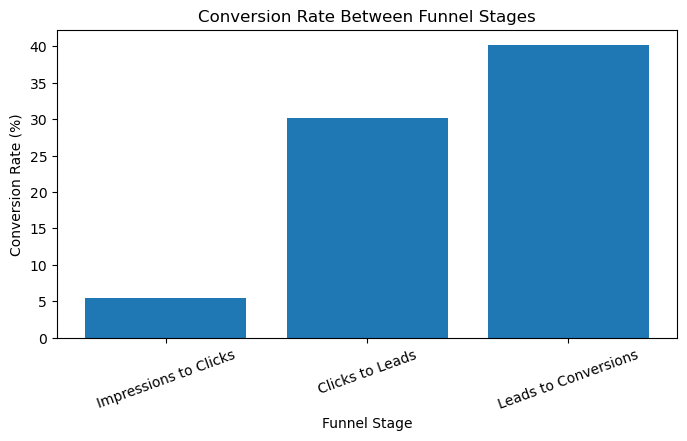

In [15]:
funnel_rates = overall_funnel.dropna().copy()

funnel_rates["StageTransition"] = [
    "Impressions to Clicks",
    "Clicks to Leads",
    "Leads to Conversions"
]

plt.figure(figsize=(8, 4))
plt.bar(funnel_rates["StageTransition"], funnel_rates["ConversionFromPreviousStage"])
plt.title("Conversion Rate Between Funnel Stages")
plt.xlabel("Funnel Stage")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=20)
plt.show()

### Overall Funnel Insight

The main funnel bottleneck at the overall level is the impression-to-click stage. This suggests that CTR is the first major efficiency point to monitor.

However, this does not automatically mean every channel has the same problem. Some channels may have stronger CTR but weaker lead or conversion performance.

Therefore, the next step is to compare funnel and efficiency metrics by marketing channel to identify where the real optimization opportunities are.

## 7. Channel Performance Analysis

This section compares campaign performance across marketing channels.

The goal is to identify which channels perform better in terms of funnel efficiency, cost efficiency, and revenue efficiency.

### 7.1 Channel Performance Summary

First, I summarize the main campaign results by marketing channel.

The KPIs are calculated from aggregated channel totals instead of simply averaging campaign-level KPIs.

In [16]:
channel_summary = df_analysis.groupby("Channel").agg({
    "CampaignID": "count",
    "Impressions": "sum",
    "Clicks": "sum",
    "Leads": "sum",
    "Conversions": "sum",
    "Cost_USD": "sum",
    "Revenue_USD": "sum"
}).reset_index()

channel_summary = channel_summary.rename(columns={"CampaignID": "Campaigns"})

channel_summary["CTR"] = channel_summary["Clicks"] / channel_summary["Impressions"] * 100
channel_summary["LeadRate"] = channel_summary["Leads"] / channel_summary["Clicks"] * 100
channel_summary["ConversionRate"] = channel_summary["Conversions"] / channel_summary["Clicks"] * 100
channel_summary["LeadToConversionRate"] = channel_summary["Conversions"] / channel_summary["Leads"] * 100
channel_summary["CAC"] = channel_summary["Cost_USD"] / channel_summary["Conversions"]
channel_summary["ROAS"] = channel_summary["Revenue_USD"] / channel_summary["Cost_USD"]

channel_summary.round(2)

,Channel,Campaigns,Impressions,Clicks,Leads,Conversions,Cost_USD,Revenue_USD,CTR,LeadRate,ConversionRate,LeadToConversionRate,CAC,ROAS
0,Display,2069,309367070,16860249,5104763,2057607,5343184.30,10715125.21,5.45,30.28,12.20,40.31,2.60,2.01
1,Email,1996,309167794,17125101,5182690,2076423,5065029.98,10130542.61,5.54,30.26,12.13,40.06,2.44,2.00
2,Influencer,2056,322458407,17509829,5257189,2101198,5278787.92,10558118.99,5.43,30.02,12.00,39.97,2.51,2.00
3,Search,1924,288572424,15932394,4843190,1951752,4916568.46,9897677.79,5.52,30.40,12.25,40.30,2.52,2.01
4,Social,1955,293040684,15962360,4736804,1920020,4919999.25,9725024.70,5.45,29.67,12.03,40.53,2.56,1.98


### 7.2 Channel KPI Ranking

Next, I review the main channel-level efficiency metrics and sort the channels by ROAS.

In [17]:
channel_kpi_ranking = channel_summary[[
    "Channel", "Campaigns", "CTR", "LeadRate", "ConversionRate",
    "LeadToConversionRate", "CAC", "ROAS"
]].sort_values("ROAS", ascending=False)

channel_kpi_ranking.round(2)

,Channel,Campaigns,CTR,LeadRate,ConversionRate,LeadToConversionRate,CAC,ROAS
3,Search,1924,5.52,30.40,12.25,40.30,2.52,2.01
0,Display,2069,5.45,30.28,12.20,40.31,2.60,2.01
2,Influencer,2056,5.43,30.02,12.00,39.97,2.51,2.00
1,Email,1996,5.54,30.26,12.13,40.06,2.44,2.00
4,Social,1955,5.45,29.67,12.03,40.53,2.56,1.98


### 7.3 ROAS by Channel

ROAS shows how much revenue is generated for each dollar spent. A higher ROAS means stronger revenue efficiency.

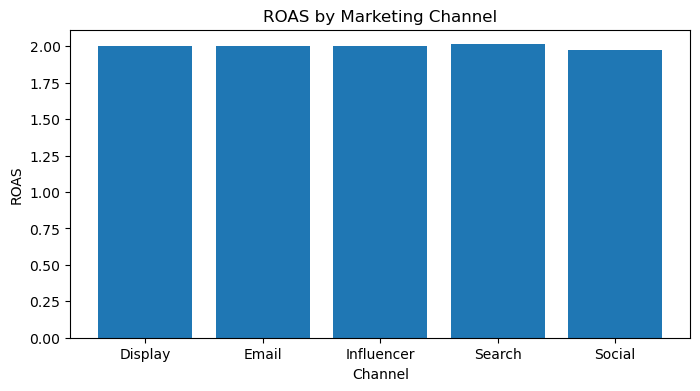

In [18]:
plt.figure(figsize=(8, 4))
plt.bar(channel_summary["Channel"], channel_summary["ROAS"])
plt.title("ROAS by Marketing Channel")
plt.xlabel("Channel")
plt.ylabel("ROAS")
plt.show()

### 7.4 CAC by Channel

CAC shows the average cost needed to generate one conversion. A lower CAC means better cost efficiency.

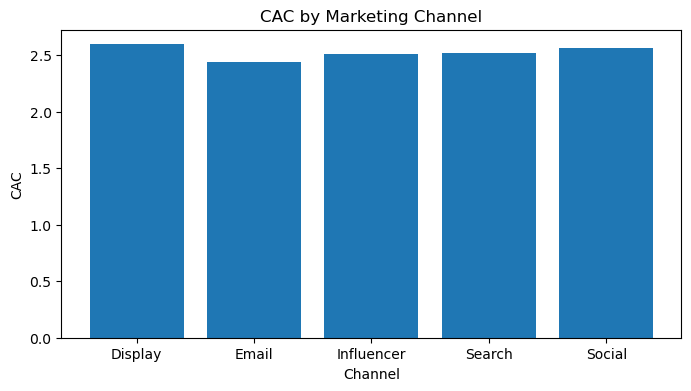

In [19]:
plt.figure(figsize=(8, 4))
plt.bar(channel_summary["Channel"], channel_summary["CAC"])
plt.title("CAC by Marketing Channel")
plt.xlabel("Channel")
plt.ylabel("CAC")
plt.show()

### Channel Performance Insight

The channel-level results show that overall performance is relatively close across channels, with only small differences in CTR, conversion rate, CAC, and ROAS.

Search has the highest conversion rate, while Email has the lowest CAC. Search and Display show the highest ROAS after rounding, while Social has the lowest ROAS among the five channels.

However, the differences are not large enough to make a strong budget decision based only on channel-level results. Instead, Search and Display should be reviewed further at campaign level to identify specific campaigns that may be worth scaling.

Email also performs well from a cost-efficiency perspective, while Social may require closer investigation before increasing budget.

Because channel-level results are quite close, the next step is to analyze campaign-level performance to identify specific campaigns that should be scaled, optimized, or reduced.

## 8. Campaign-Level Performance Analysis

This section analyzes performance at individual campaign level.

The goal is to identify specific campaigns that perform strongly or weakly, instead of relying only on channel-level averages.

### 8.1 Campaign Performance Table

First, I create a campaign-level performance table with the main volume, cost, revenue, and KPI columns.

In [20]:
campaign_perf = df_analysis[[
    "CampaignID", "Channel", "Impressions", "Clicks", "Leads", "Conversions",
    "Cost_USD", "Revenue_USD", "CTR", "LeadRate", "ConversionRate", "CAC", "ROAS"
]].copy()

campaign_perf.head().round(4)

,CampaignID,Channel,Impressions,Clicks,Leads,Conversions,Cost_USD,Revenue_USD,CTR,LeadRate,ConversionRate,CAC,ROAS
0,CAMP00001,Search,293520,23335,11643,5389,1052.39,2236.02,0.0795,0.4990,0.2309,0.1953,2.1247
1,CAMP00002,Search,200340,15841,6601,2498,3964.90,11740.15,0.0791,0.4167,0.1577,1.5872,2.9610
2,CAMP00003,Email,239365,16478,8043,3397,1000.39,1902.24,0.0688,0.4881,0.2062,0.2945,1.9015
3,CAMP00004,Search,156382,2672,1014,342,1252.63,2209.74,0.0171,0.3795,0.1280,3.6627,1.7641
4,CAMP00005,Influencer,285472,4155,1521,565,4935.48,14111.31,0.0146,0.3661,0.1360,8.7354,2.8592


### 8.2 Top Campaigns by ROAS

Next, I identify the campaigns with the highest ROAS.

These campaigns generate the most revenue for each dollar spent.

In [21]:
top_roas_campaigns = campaign_perf.sort_values("ROAS", ascending=False).head(10)

top_roas_campaigns[[
    "CampaignID", "Channel", "Cost_USD", "Revenue_USD",
    "Conversions", "CAC", "ROAS"
]].round(2)

,CampaignID,Channel,Cost_USD,Revenue_USD,Conversions,CAC,ROAS
1392,CAMP01393,Display,3381.99,10145.25,615,5.50,3.0
3078,CAMP03079,Display,3317.83,9952.74,876,3.79,3.0
6095,CAMP06096,Social,4482.07,13445.01,737,6.08,3.0
5961,CAMP05962,Search,2861.45,8583.51,713,4.01,3.0
3299,CAMP03300,Social,4433.01,13297.63,946,4.69,3.0
6681,CAMP06682,Display,4857.38,14568.71,1698,2.86,3.0
8871,CAMP08872,Search,1795.33,5384.35,2460,0.73,3.0
5706,CAMP05707,Influencer,2433.02,7296.13,2557,0.95,3.0
3801,CAMP03802,Email,1008.66,3024.51,1455,0.69,3.0
5241,CAMP05242,Email,3561.23,10677.88,35,101.75,3.0


### 8.3 Bottom Campaigns by ROAS

I also check the campaigns with the lowest ROAS.

These campaigns generate the least revenue for each dollar spent and may need closer review.

In [22]:
bottom_roas_campaigns = campaign_perf.sort_values("ROAS", ascending=True).head(10)

bottom_roas_campaigns[[
    "CampaignID", "Channel", "Cost_USD", "Revenue_USD",
    "Conversions", "CAC", "ROAS"
]].round(2)

,CampaignID,Channel,Cost_USD,Revenue_USD,Conversions,CAC,ROAS
4550,CAMP04551,Search,2207.69,2208.46,1793,1.23,1.0
3985,CAMP03986,Social,4944.24,4948.07,118,41.90,1.0
9974,CAMP09975,Influencer,1157.99,1159.02,32,36.19,1.0
112,CAMP00113,Influencer,498.28,498.97,985,0.51,1.0
9377,CAMP09378,Email,3162.47,3167.59,1258,2.51,1.0
673,CAMP00674,Display,3069.42,3074.40,698,4.40,1.0
7540,CAMP07541,Search,2752.33,2756.89,11,250.21,1.0
5327,CAMP05328,Email,4003.56,4010.55,775,5.17,1.0
5699,CAMP05700,Search,3805.40,3812.57,772,4.93,1.0
4032,CAMP04033,Search,3713.98,3721.18,1403,2.65,1.0


### 8.4 High Cost, Low Return Campaigns

Then, I look for campaigns with above-average cost but below-average ROAS.

These campaigns may be inefficient because they spend more than average but generate weaker return.

In [23]:
avg_cost = campaign_perf["Cost_USD"].mean()
avg_roas = campaign_perf["ROAS"].mean()

high_cost_low_return = campaign_perf[
    (campaign_perf["Cost_USD"] > avg_cost) &
    (campaign_perf["ROAS"] < avg_roas)
].sort_values("ROAS")

high_cost_low_return[[
    "CampaignID", "Channel", "Cost_USD", "Revenue_USD",
    "Conversions", "CAC", "ROAS"
]].head(10).round(2)

,CampaignID,Channel,Cost_USD,Revenue_USD,Conversions,CAC,ROAS
3985,CAMP03986,Social,4944.24,4948.07,118,41.90,1.0
9377,CAMP09378,Email,3162.47,3167.59,1258,2.51,1.0
673,CAMP00674,Display,3069.42,3074.40,698,4.40,1.0
7540,CAMP07541,Search,2752.33,2756.89,11,250.21,1.0
5327,CAMP05328,Email,4003.56,4010.55,775,5.17,1.0
5699,CAMP05700,Search,3805.40,3812.57,772,4.93,1.0
4032,CAMP04033,Search,3713.98,3721.18,1403,2.65,1.0
7147,CAMP07148,Social,3795.29,3804.28,2726,1.39,1.0
5227,CAMP05228,Display,3799.09,3808.94,783,4.85,1.0
6048,CAMP06049,Search,4129.99,4141.73,284,14.54,1.0


### 8.5 Strong Campaign Candidates

Finally, I identify campaigns with above-average ROAS and below-average CAC.

These campaigns are potential candidates for further review because they show both above-average revenue efficiency and below-average conversion cost.

In [24]:
avg_cac = campaign_perf["CAC"].mean()

strong_campaigns = campaign_perf[
    (campaign_perf["ROAS"] > avg_roas) &
    (campaign_perf["CAC"] < avg_cac)
].sort_values("ROAS", ascending=False)

strong_campaigns[[
    "CampaignID", "Channel", "Cost_USD", "Revenue_USD",
    "Conversions", "CAC", "ROAS"
]].head(10).round(2)

,CampaignID,Channel,Cost_USD,Revenue_USD,Conversions,CAC,ROAS
1392,CAMP01393,Display,3381.99,10145.25,615,5.50,3.0
3078,CAMP03079,Display,3317.83,9952.74,876,3.79,3.0
6095,CAMP06096,Social,4482.07,13445.01,737,6.08,3.0
5961,CAMP05962,Search,2861.45,8583.51,713,4.01,3.0
3299,CAMP03300,Social,4433.01,13297.63,946,4.69,3.0
6681,CAMP06682,Display,4857.38,14568.71,1698,2.86,3.0
8871,CAMP08872,Search,1795.33,5384.35,2460,0.73,3.0
5706,CAMP05707,Influencer,2433.02,7296.13,2557,0.95,3.0
3801,CAMP03802,Email,1008.66,3024.51,1455,0.69,3.0
3000,CAMP03001,Search,1655.51,4963.65,213,7.77,3.0


### Campaign-Level Performance Insight

The campaign-level analysis shows that even when channel-level performance looks close, individual campaigns can perform very differently.

The top ROAS campaigns generate stronger revenue efficiency, but ROAS alone should not be the only decision metric. CAC and conversion volume should also be reviewed before deciding whether a campaign should receive more budget.

The weaker campaigns are those with high cost and low ROAS. These campaigns should be reviewed before increasing budget, because they may be wasting spend or attracting lower-quality traffic.

This campaign-level view provides a stronger basis for campaign prioritization than channel-level averages alone.

## 9. Campaign Prioritization

This section groups campaigns into simple priority categories based on ROAS, CAC, conversion volume, CTR, and conversion rate.

The goal is to translate campaign metrics into practical action groups for marketing decision-making.

### 9.1 Define Prioritization Rules

First, I define simple benchmark values using median metrics.

Median is used instead of mean because some campaign metrics, especially CAC, can be affected by very high values.

In [25]:
median_roas = campaign_perf["ROAS"].median()
median_cac = campaign_perf["CAC"].median()
median_conversions = campaign_perf["Conversions"].median()
median_ctr = campaign_perf["CTR"].median()
median_conversion_rate = campaign_perf["ConversionRate"].median()

threshold_summary = pd.DataFrame({
    "Metric": [
        "Median ROAS",
        "Median CAC",
        "Median Conversions",
        "Median CTR",
        "Median Conversion Rate"
    ],
    "Value": [
        median_roas,
        median_cac,
        median_conversions,
        median_ctr,
        median_conversion_rate
    ]
})

threshold_summary.round(4)

,Metric,Value
0,Median ROAS,1.9926
1,Median CAC,3.2662
2,Median Conversions,670.0000
3,Median CTR,0.0544
4,Median Conversion Rate,0.1107


### 9.2 Assign Priority Groups

Next, I assign each campaign into a priority group using simple business rules.

The rules are designed to identify campaigns that may be worth reviewing for scaling, optimization, investigation, or budget reduction.

In [26]:
campaign_priority = campaign_perf.copy()

def assign_priority(row):
    if (row["ROAS"] >= median_roas) and (row["CAC"] <= median_cac) and (row["Conversions"] >= median_conversions):
        return "Scale Review"
    elif (row["ROAS"] < median_roas) and (row["CAC"] > median_cac):
        return "Reduce / Pause Review"
    elif (row["CTR"] >= median_ctr) and (row["ConversionRate"] < median_conversion_rate):
        return "Optimize"
    else:
        return "Investigate"

campaign_priority["PriorityGroup"] = campaign_priority.apply(assign_priority, axis=1)

priority_counts = campaign_priority["PriorityGroup"].value_counts().reset_index()
priority_counts.columns = ["Priority Group", "Campaigns"]

priority_counts

,Priority Group,Campaigns
0,Investigate,3998
1,Reduce / Pause Review,2542
2,Scale Review,2086
3,Optimize,1374


### 9.3 Priority Group Summary

Then, I summarize the average performance of each priority group.

In [27]:
priority_summary = campaign_priority.groupby("PriorityGroup").agg(
    Campaigns=("CampaignID", "count"),
    TotalCost=("Cost_USD", "sum"),
    TotalRevenue=("Revenue_USD", "sum"),
    TotalConversions=("Conversions", "sum"),
    AvgCTR=("CTR", "mean"),
    AvgConversionRate=("ConversionRate", "mean"),
    AvgCAC=("CAC", "mean"),
    AvgROAS=("ROAS", "mean")
).reset_index()

priority_summary["AvgCTR"] = priority_summary["AvgCTR"] * 100
priority_summary["AvgConversionRate"] = priority_summary["AvgConversionRate"] * 100

priority_summary.round(2)

,PriorityGroup,Campaigns,TotalCost,TotalRevenue,TotalConversions,AvgCTR,AvgConversionRate,AvgCAC,AvgROAS
0,Investigate,3998,9571138.85,20338492.03,3939504,4.59,13.60,9.77,2.04
1,Optimize,1374,3301180.95,7116476.67,1132120,7.71,7.24,7.08,2.04
2,Reduce / Pause Review,2542,8088616.15,12158867.42,1007433,4.50,10.17,20.02,1.50
3,Scale Review,2086,4562633.96,11412653.18,4027943,6.83,14.76,1.34,2.50


### 9.4 Example Campaigns by Priority Group

I review example campaigns from each priority group to make the prioritization easier to understand.

In [28]:
example_campaigns = (
    campaign_priority
    .sort_values(["PriorityGroup", "ROAS"], ascending=[True, False])
    .groupby("PriorityGroup")
    .head(5)
)

example_campaigns[[
    "CampaignID", "Channel", "PriorityGroup", "Cost_USD", "Revenue_USD",
    "Conversions", "CTR", "ConversionRate", "CAC", "ROAS"
]].round(4)

,CampaignID,Channel,PriorityGroup,Cost_USD,Revenue_USD,Conversions,CTR,ConversionRate,CAC,ROAS
1392,CAMP01393,Display,Investigate,3381.99,10145.25,615,0.0683,0.1484,5.4992,2.9998
3078,CAMP03079,Display,Investigate,3317.83,9952.74,876,0.0681,0.1246,3.7875,2.9998
6095,CAMP06096,Social,Investigate,4482.07,13445.01,737,0.0708,0.1142,6.0815,2.9997
3000,CAMP03001,Search,Investigate,1655.51,4963.65,213,0.0129,0.2180,7.7723,2.9983
7826,CAMP07827,Email,Investigate,4758.23,14261.79,771,0.0444,0.0596,6.1715,2.9973
5961,CAMP05962,Search,Optimize,2861.45,8583.51,713,0.0926,0.0768,4.0133,2.9997
3299,CAMP03300,Social,Optimize,4433.01,13297.63,946,0.0628,0.0699,4.6861,2.9997
5241,CAMP05242,Email,Optimize,3561.23,10677.88,35,0.0971,0.0517,101.7494,2.9984
2749,CAMP02750,Search,Optimize,101.02,302.73,484,0.0700,0.0794,0.2087,2.9967
142,CAMP00143,Search,Optimize,3743.41,11217.85,44,0.0706,0.0428,85.0775,2.9967


### 9.5 Action Guide

Finally, I define the suggested business action for each priority group.

| Priority Group | Meaning | Suggested Action |
|---|---|---|
| Scale Review | Strong revenue efficiency, lower conversion cost, and solid conversion volume | Review for controlled budget increase |
| Optimize | Good click performance but weaker conversion efficiency | Improve landing page, offer, targeting, or post-click experience |
| Investigate | Mixed performance that needs more context before action | Check campaign objective, audience, creative, and tracking |
| Reduce / Pause Review | Weak return and higher conversion cost | Reduce budget, pause, or redesign before spending more |

### Campaign Prioritization Insight

The prioritization framework converts campaign metrics into practical action groups.

The Scale Review group has stronger ROAS, lower CAC, and solid conversion volume. These campaigns may be worth reviewing for controlled budget increase.

The Reduce / Pause Review group has weaker ROAS and higher CAC. These campaigns should be reviewed carefully before receiving more budget.

The Optimize group has stronger click performance but weaker conversion efficiency. This suggests that post-click experience, offer, targeting, or landing page quality should be checked.

The Investigate group has mixed performance and needs more context before a clear action is taken.

This prioritization is rule-based and should be used as a decision-support framework, not as an automatic final decision.

## 10. Business Recommendations and Final Conclusion

This section summarizes the key findings from the funnel, channel, campaign-level, and prioritization analysis.

The goal is to turn the analysis into practical business recommendations.

### 10.1 Key Findings

The analysis shows four main findings:

1. The biggest funnel drop-off happens from impressions to clicks. Only 5.48% of impressions become clicks, meaning CTR is the first major efficiency point to monitor.

2. Channel-level performance is relatively close across Search, Display, Email, Influencer, and Social. This means channel-level results alone are not enough to make strong budget decisions.

3. Campaign-level performance shows clearer differences than channel-level performance. Some campaigns have strong ROAS and low CAC, while others spend more but generate weaker return.

4. The rule-based prioritization framework helps separate campaigns into action groups: Scale Review, Optimize, Investigate, and Reduce / Pause Review.

### 10.2 Business Recommendations

| Priority | Recommendation | Reason | Expected Business Impact |
|---|---|---|---|
| 1 | Review Scale Review campaigns for controlled budget increase | These campaigns show stronger ROAS, lower CAC, and solid conversion volume | Increase revenue while keeping conversion cost controlled |
| 2 | Review Reduce / Pause Review campaigns before giving more budget | These campaigns show weaker ROAS and higher CAC | Reduce wasted spend and improve budget efficiency |
| 3 | Optimize campaigns with strong CTR but weak conversion rate | These campaigns may attract clicks but fail to convert efficiently | Improve post-click conversion and reduce inefficient traffic |
| 4 | Investigate mixed-performance campaigns before making budget decisions | These campaigns do not clearly fit into strong or weak groups | Avoid premature decisions and identify hidden opportunities |
| 5 | Continue using campaign-level analysis instead of relying only on channel averages | Channel-level performance is close, while campaign-level performance reveals clearer differences | Make more precise campaign optimization decisions |

### 10.3 Recommended Next Actions

Based on the analysis, the marketing team should take the following next actions:

1. Start with the Scale Review group and check whether these campaigns can handle a controlled budget increase without losing efficiency.

2. Review the Reduce / Pause Review group to decide whether these campaigns should be paused, reduced, or redesigned.

3. For the Optimize group, investigate landing pages, offers, targeting, and post-click experience because these campaigns show click potential but weaker conversion efficiency.

4. For the Investigate group, collect more context such as campaign objective, audience type, creative format, and landing page before making a final decision.

5. Track CTR, conversion rate, CAC, and ROAS regularly because these metrics connect funnel performance with business efficiency.

### 10.4 Limitations

This analysis has some limitations:

- The dataset is campaign-level, so it does not include user-level behavior.
- The dataset does not include creative type, landing page, audience segment, device, or campaign objective.
- The prioritization framework is rule-based, so it should support decision-making but should not replace business judgment.
- The analysis identifies performance patterns, but it does not prove the exact cause of each campaign's performance.
- More data would be needed to understand why specific campaigns perform better or worse.

### 10.5 Final Conclusion

This project analyzed marketing campaign performance across the full funnel from impressions to clicks, leads, and conversions.

The overall funnel analysis showed that the largest efficiency loss happens at the impression-to-click stage. Channel-level analysis showed that performance is relatively close across channels, so channel averages alone are not enough for strong budget decisions.

Campaign-level analysis provided more useful insight by identifying strong campaigns, weak campaigns, high-cost low-return campaigns, and potential scale candidates.

The final prioritization framework grouped campaigns into practical action categories: Scale Review, Optimize, Investigate, and Reduce / Pause Review.

Overall, this project shows how marketing campaign data can be used not only to report performance, but also to support budget allocation, campaign optimization, and performance improvement decisions.